<a href="https://colab.research.google.com/github/YashavanthaMS/Portfolio-/blob/main/QC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install -q pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [1]:
!pip install qiskit qiskit-aer matplotlib scipy qiskit-ibm-runtime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 9.9 MB/s eta 0:00:00


In [3]:
import qiskit
from qiskit_aer import AerSimulator

print("="*50)
print(" EASY: INSTALLATION & BACKEND VERIFICATION ")
print("="*50)

# Verify Qiskit version
print(f"✅ Qiskit Version: {qiskit.__version__}")

# Initialize local Aer simulator
sim = AerSimulator()
print(f"✅ Aer Simulator Initialized: {sim.name}")
print(f"Available Aer Methods: {sim.available_methods()[:4]}")

 EASY: INSTALLATION & BACKEND VERIFICATION 
✅ Qiskit Version: 2.5.0
✅ Aer Simulator Initialized: aer_simulator
Available Aer Methods: ('automatic', 'statevector', 'density_matrix', 'stabilizer')


1-Qubit Measurement Counts (1024 shots): {'0': 520, '1': 504}

Circuit Diagram:
     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


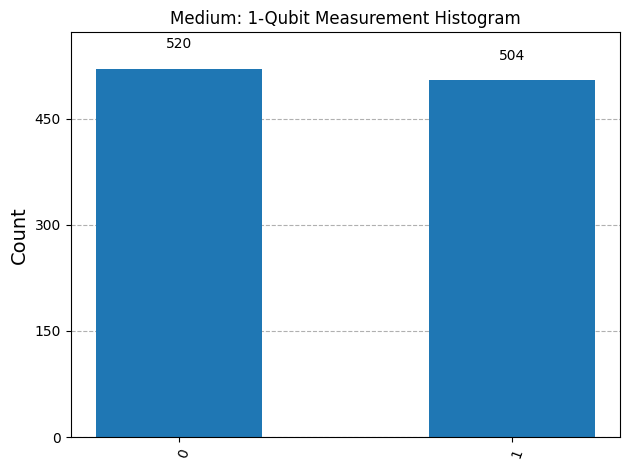

In [11]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# 1. Create circuit
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

# 2. Simulate
sim = AerSimulator()
compiled_qc = transpile(qc, sim)
counts = sim.run(compiled_qc, shots=1024).result().get_counts()

print("1-Qubit Measurement Counts (1024 shots):", counts)

# 3. Graphical Output 1: Text Circuit Diagram (Works instantly without pylatexenc!)
print("\nCircuit Diagram:")
print(qc.draw())

# 4. Graphical Output 2: Histogram (Uses Matplotlib natively)
display(plot_histogram(counts, title="Medium: 1-Qubit Measurement Histogram"))

🎯 Theoretical Probability per state: 0.1250 (1/8)

State Empirical Probabilities:
  |000⟩: 0.1279 (Count: 1048)
  |001⟩: 0.1298 (Count: 1063)
  |010⟩: 0.1246 (Count: 1021)
  |011⟩: 0.1223 (Count: 1002)
  |100⟩: 0.1216 (Count: 996)
  |101⟩: 0.1223 (Count: 1002)
  |110⟩: 0.1296 (Count: 1062)
  |111⟩: 0.1218 (Count: 998)

Circuit Diagram:
     ┌───┐┌─┐      
q_0: ┤ H ├┤M├──────
     ├───┤└╥┘┌─┐   
q_1: ┤ H ├─╫─┤M├───
     ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├─╫──╫─┤M├
     └───┘ ║  ║ └╥┘
c: 3/══════╩══╩══╩═
           0  1  2 


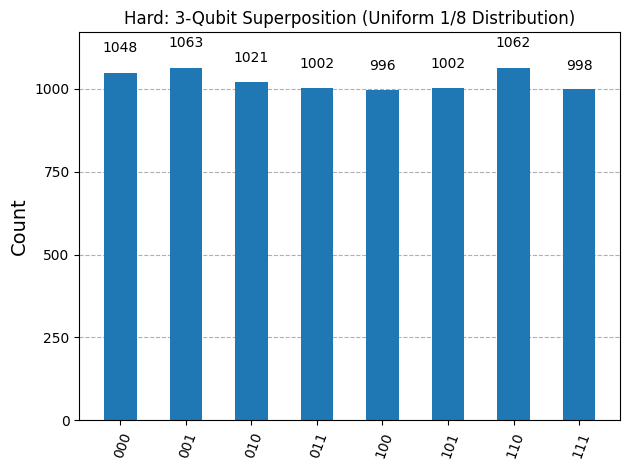

In [12]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# 1. Create a 3-qubit, 3-classical bit circuit
n_qubits = 3
qc3 = QuantumCircuit(n_qubits, n_qubits)

# Apply Hadamard gate to all 3 qubits
for q in range(n_qubits):
    qc3.h(q)

qc3.measure(range(n_qubits), range(n_qubits))

# 2. Simulate with 8192 shots for statistical precision
shots = 8192
sim = AerSimulator()
compiled_qc3 = transpile(qc3, sim)
counts3 = sim.run(compiled_qc3, shots=shots).result().get_counts()

# 3. Print Probability Breakdown
print(f"🎯 Theoretical Probability per state: {1/8:.4f} (1/8)\n")
print("State Empirical Probabilities:")
for state in sorted(counts3.keys()):
    prob = counts3[state] / shots
    print(f"  |{state}⟩: {prob:.4f} (Count: {counts3[state]})")

# 4. Circuit Diagram (Pure Text - Always works without dependencies)
print("\nCircuit Diagram:")
print(qc3.draw())

# 5. Graphical Output: Uniform Probability Histogram
display(plot_histogram(counts3, title="Hard: 3-Qubit Superposition (Uniform 1/8 Distribution)"))

📊 Statistical Summary (1000 bits generated):
  QRNG -> Ones: 506 (50.6%) | Zeros: 494 (49.4%)
  PRNG -> Ones: 523 (52.3%) | Zeros: 477 (47.7%)


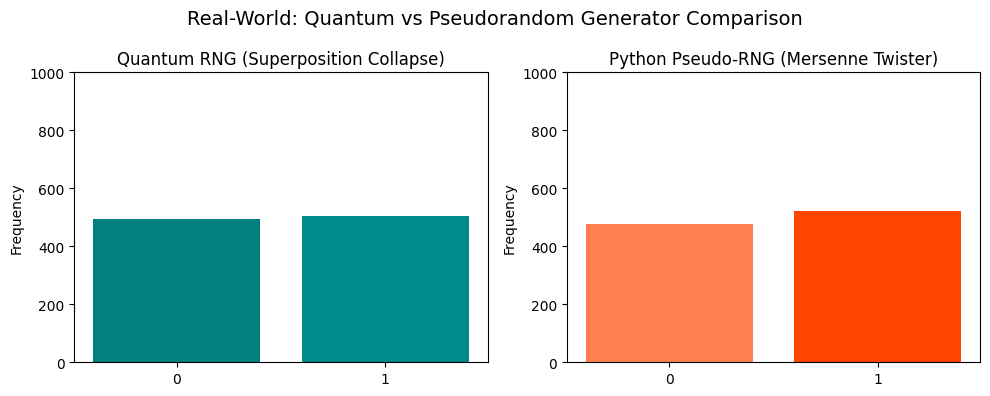

In [13]:
import random
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# 1. Initialize Aer Simulator
sim = AerSimulator()

def generate_quantum_bits(length=1000):
    """Generates quantum random bits using Hadamard superposition collapse."""
    qc = QuantumCircuit(1, 1)
    qc.h(0)           # Create superposition: (|0> + |1>) / sqrt(2)
    qc.measure(0, 0)  # Collapse state upon measurement

    t_qc = transpile(qc, sim)
    counts = sim.run(t_qc, shots=length).result().get_counts()

    # Extract bit outcomes
    zeros = [0] * counts.get('0', 0)
    ones = [1] * counts.get('1', 0)
    bits = zeros + ones
    random.shuffle(bits)
    return bits

# 2. Generate 1000 bits from both sources
N = 1000
qrng_bits = generate_quantum_bits(N)
prng_bits = [random.choice([0, 1]) for _ in range(N)]

q_ones, p_ones = sum(qrng_bits), sum(prng_bits)

# 3. Print Statistical Output
print(f"📊 Statistical Summary ({N} bits generated):")
print(f"  QRNG -> Ones: {q_ones} ({q_ones/N:.1%}) | Zeros: {N-q_ones} ({(N-q_ones)/N:.1%})")
print(f"  PRNG -> Ones: {p_ones} ({p_ones/N:.1%}) | Zeros: {N-p_ones} ({(N-p_ones)/N:.1%})")

# 4. Graphical Output: Side-by-Side Comparison Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["0", "1"], [N - q_ones, q_ones], color=['teal', 'darkcyan'])
axes[0].set_title("Quantum RNG (Superposition Collapse)")
axes[0].set_ylabel("Frequency")
axes[0].set_ylim(0, N)

axes[1].bar(["0", "1"], [N - p_ones, p_ones], color=['coral', 'orangered'])
axes[1].set_title("Python Pseudo-RNG (Mersenne Twister)")
axes[1].set_ylabel("Frequency")
axes[1].set_ylim(0, N)

plt.suptitle("Real-World: Quantum vs Pseudorandom Generator Comparison", fontsize=14)
plt.tight_layout()
plt.show()

Ideal Simulator Counts (Only |000> and |111>):
  {'111': 1038, '000': 1010}

Noisy Hardware-like Simulator Counts (Includes error states like |001>, |010>, etc.):
  {'110': 15, '100': 13, '101': 48, '001': 21, '010': 42, '000': 941, '011': 10, '111': 958}

GHZ Entanglement Circuit Diagram:
     ┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2 


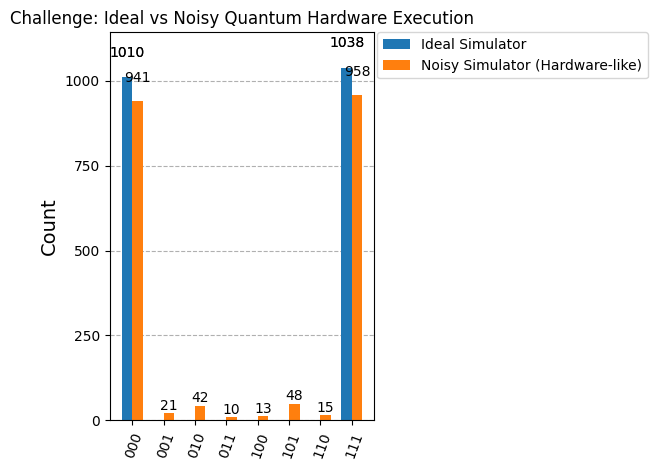

In [14]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram

# 1. Create a 3-qubit GHZ state circuit (|000> + |111>) / sqrt(2)
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
qc.measure([0, 1, 2], [0, 1, 2])

shots = 2048

# 2. Run Ideal Simulation
ideal_sim = AerSimulator()
t_qc_ideal = transpile(qc, ideal_sim)
ideal_counts = ideal_sim.run(t_qc_ideal, shots=shots).result().get_counts()

# 3. Build a Hardware-like Noise Model (Depolarizing gate errors)
noise_model = NoiseModel()
error_1q = depolarizing_error(0.02, 1)  # 2% error on 1-qubit gates (H gate)
error_2q = depolarizing_error(0.06, 2)  # 6% error on 2-qubit gates (CX gates)
noise_model.add_all_qubit_quantum_error(error_1q, ['h'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

# Run Noisy Simulation
noisy_sim = AerSimulator(noise_model=noise_model)
t_qc_noisy = transpile(qc, noisy_sim)
noisy_counts = noisy_sim.run(t_qc_noisy, shots=shots).result().get_counts()

# 4. Print Results
print("Ideal Simulator Counts (Only |000> and |111>):")
print(" ", ideal_counts)
print("\nNoisy Hardware-like Simulator Counts (Includes error states like |001>, |010>, etc.):")
print(" ", noisy_counts)

# 5. Graphical Output 1: Text Circuit Diagram
print("\nGHZ Entanglement Circuit Diagram:")
print(qc.draw())

# 6. Graphical Output 2: Comparative Histogram Plot
display(plot_histogram(
    [ideal_counts, noisy_counts],
    legend=["Ideal Simulator", "Noisy Simulator (Hardware-like)"],
    title="Challenge: Ideal vs Noisy Quantum Hardware Execution"
))